In [33]:
# to handle the data
import pandas as pd
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

import numpy as np

# to visualize the data
import matplotlib.pyplot as plt
import seaborn as sns

#preprocessing
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder,OneHotEncoder

# machine learning
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, RandomizedSearchCV

# pipeline
from sklearn.pipeline import Pipeline

# metrics
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, mean_absolute_error,mean_squared_error,r2_score

#warnings
import warnings
warnings.filterwarnings('ignore')


In [34]:
columns = [
    'Class', 'Alcohol', 'Malic_acid', 'Ash', 'Alcalinity_of_ash', 
    'Magnesium', 'Total_phenols', 'Flavanoids', 'Nonflavanoid_phenols', 
    'Proanthocyanins', 'Color_intensity', 'Hue', 'OD280/OD315', 'Proline'
]

df = pd.read_csv("wine.data", header=None, names=columns)
df.head()

,Class,Alcohol,Malic_acid,Ash,Alcalinity_of_ash,Magnesium,Total_phenols,Flavanoids,Nonflavanoid_phenols,Proanthocyanins,Color_intensity,Hue,OD280/OD315,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [35]:
df.shape

(178, 14)

In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Class                 178 non-null    int64  
 1   Alcohol               178 non-null    float64
 2   Malic_acid            178 non-null    float64
 3   Ash                   178 non-null    float64
 4   Alcalinity_of_ash     178 non-null    float64
 5   Magnesium             178 non-null    int64  
 6   Total_phenols         178 non-null    float64
 7   Flavanoids            178 non-null    float64
 8   Nonflavanoid_phenols  178 non-null    float64
 9   Proanthocyanins       178 non-null    float64
 10  Color_intensity       178 non-null    float64
 11  Hue                   178 non-null    float64
 12  OD280/OD315           178 non-null    float64
 13  Proline               178 non-null    int64  
dtypes: float64(11), int64(3)
memory usage: 19.6 KB


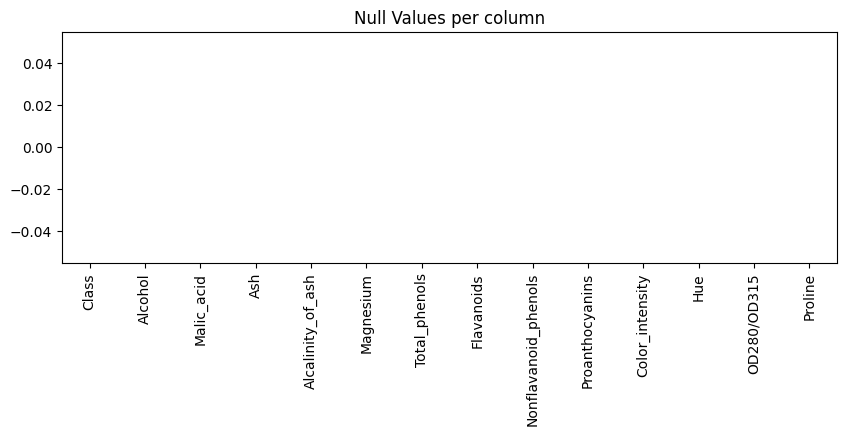

Class                   0
Alcohol                 0
Malic_acid              0
Ash                     0
Alcalinity_of_ash       0
Magnesium               0
Total_phenols           0
Flavanoids              0
Nonflavanoid_phenols    0
Proanthocyanins         0
Color_intensity         0
Hue                     0
OD280/OD315             0
Proline                 0
dtype: int64

In [37]:
df.isnull().sum().plot(kind="bar", figsize=(10,3))
plt.title("Null Values per column")
plt.show()

df.isnull().sum()

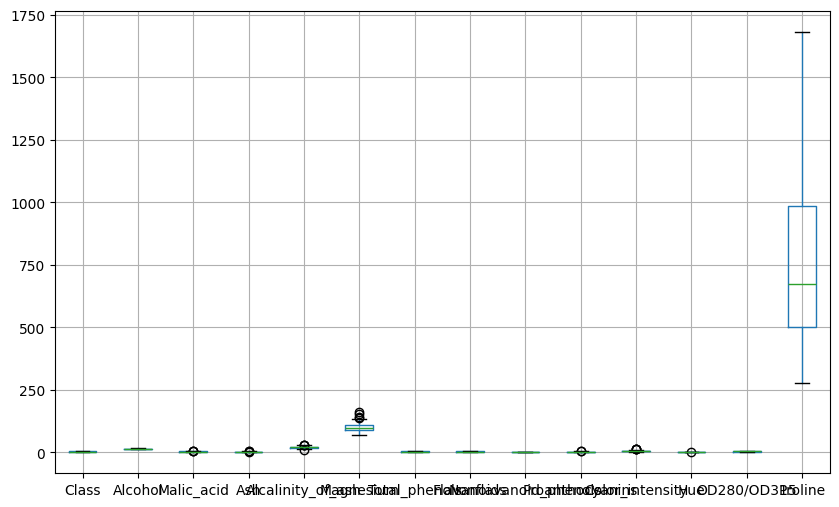

In [38]:
df.boxplot(figsize=(10,6))
plt.show()

In [39]:
for col in df.columns:
    print(f'{col} : {df[col].nunique()}')
    
#we have 3 classes of wine

Class : 3
Alcohol : 126
Malic_acid : 133
Ash : 79
Alcalinity_of_ash : 63
Magnesium : 53
Total_phenols : 97
Flavanoids : 132
Nonflavanoid_phenols : 39
Proanthocyanins : 101
Color_intensity : 132
Hue : 78
OD280/OD315 : 122
Proline : 121


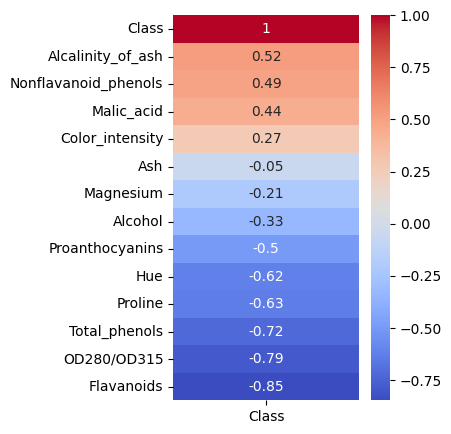

In [40]:
corr = df.corr()

plt.figure(figsize=(3,5))
sns.heatmap(corr[['Class']].sort_values(by='Class', ascending=False), 
            annot=True, cmap="coolwarm")
plt.show()

In [41]:
X = df.drop(columns=['Class'], axis=1)

In [42]:
scaler = StandardScaler()

X = scaler.fit_transform(X)


In [43]:
from sklearn.cluster import KMeans

wcss = []
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)


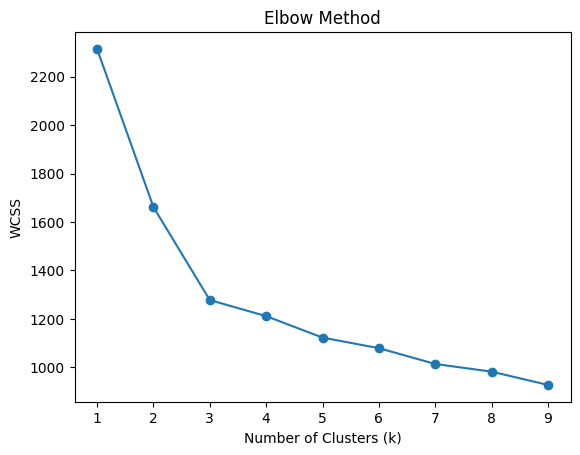

In [44]:
plt.plot(range(1, 10), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS")
plt.show()

In [45]:
kmeans = KMeans(n_clusters=3, random_state=42)
y = kmeans.fit_predict(X)

In [46]:
df['Cluster'] = y

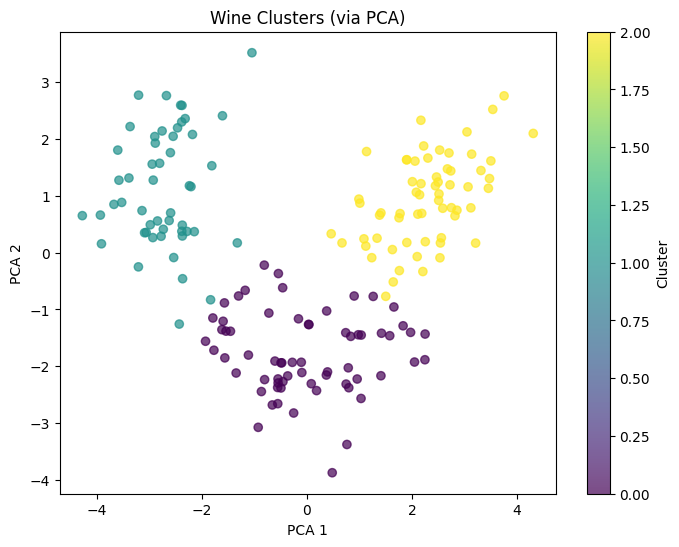

In [52]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis', alpha=0.7)
plt.title("Wine Clusters (via PCA)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.colorbar(label="Cluster")
plt.show()
